# Tahap 3 — Case Retrieval (TF-IDF + SVM) (IMPROVED)

### Perbaikan:
- **TF-IDF teroptimasi** dengan `sublinear_tf=True`, tuning parameter
- **Cross-Validation** dengan `StratifiedKFold` untuk analisis overfitting
- **Improved Retrieval** dengan similarity threshold dan penjelasan
- **Visualisasi profesional** (Top TF-IDF features, similarity distribution)

## 1. Import Library

In [1]:
import os
import re
import json
import joblib
import pandas as pd
import numpy as np
from tqdm import tqdm

import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


## 2. Load Dataset

In [2]:
base_path = "../"
csv_path = os.path.join(base_path, "data/processed/cases.csv")

df_cases = pd.read_csv(csv_path)
df_cases = df_cases.dropna(subset=['text_full', 'amar_putusan'])

print(f"Total dokumen termuat: {len(df_cases)}")
print(f"\nDistribusi Label:")
print(df_cases['label'].value_counts())

# Verifikasi kualitas teks (PENTING: pastikan tidak ada noise huruf tunggal)
sample_text = df_cases.iloc[0]['text_full']
single_chars = [t for t in sample_text.split() if len(t) == 1]
print(f"\nVerifikasi Kualitas Teks (case_001):")
print(f"  Token huruf tunggal: {len(single_chars)}")
print(f"  Sampel: {sample_text[:200]}")

df_cases.head(2)

Total dokumen termuat: 62

Distribusi Label:
label
dikabulkan    46
ditolak       16
Name: count, dtype: int64

Verifikasi Kualitas Teks (case_001):
  Token huruf tunggal: 0
  Sampel: pdt pa srl bismillahirrahmanirrahim gdemi adil tuhan maha esad sarolangun emeriksa adil tingkat sidang jatuh cerai gugat gugat umur taheun islam kerja tani pendidrikan sd tinggal kabupaten saro langun


,case_id,no_perkara,tanggal,jenis_perkara,ringkasan_fakta,pasal,pihak,amar_putusan,alasan_perceraian,label,text_length,token_count,unique_word_count,text_full
0,case_001,033/Pdt.G/2011/PA.Srl,18 April 2011,Cerai Gugat,"Perceraian didasari oleh faktor: pertengkaran,...","Pasal 31 Peraturan Pemerintah Nomor 9 Tahun, P...",PENGGUGAT vs ELAS DAN PASTI DII WILAYAH REPUBL...,M g e 1. Menyatakan Tergugat yang telah dipang...,"pertengkaran, ekonomi, meninggalkan, judi",dikabulkan,12414,1903,596,pdt pa srl bismillahirrahmanirrahim gdemi adil...
1,case_002,0007/Pdt.G/2013/PA.KP,26 Juni 2013,Cerai Gugat,"Perceraian didasari oleh faktor: pertengkaran,...","Pasal 3n09 Rbg, pasal 89 ayat ( 1 ) Undang-Und...",tidak ditemukan,b 1 Mengabulkan permohonan Pemohon sebagian; u...,"pertengkaran, ekonomi, kekerasan, selingkuh",ditolak,15895,2487,688,gnomor pdt pa kp bismillahirrahmanirrahim adil...


## 3. Penanganan Imbalanced Class & Preprocessing Query

In [3]:
# Penanganan Single Class (jika semua label sama)
unique_labels = df_cases['label'].unique()
if len(unique_labels) < 2:
    print(f"\n[WARNING] Dataset hanya memiliki 1 kelas label: {unique_labels[0]}")
    print("Menambahkan data sintetis untuk training SVM...")
    
    dummy_1 = df_cases.iloc[0].copy()
    dummy_1['label'] = 'ditolak'
    dummy_1['amar_putusan'] = 'menolak gugatan penggugat seluruhnya'
    dummy_1['text_full'] = 'gugatan cerai tolak alasan bukti sah hukum saksi hadir sidang pertimbang hakim tolak seluruh'
    
    dummy_2 = df_cases.iloc[1 % len(df_cases)].copy()
    dummy_2['label'] = 'dikabulkan sebagian'
    dummy_2['amar_putusan'] = 'mengabulkan sebagian gugatan penggugat'
    dummy_2['text_full'] = 'kabul cerai namun tolak tuntut hak asuh anak harta bersama bagi nafkah iddah mutah'
    
    df_cases = pd.concat([df_cases, pd.DataFrame([dummy_1, dummy_2])], ignore_index=True)

print(f"Distribusi Label Akhir:")
print(df_cases['label'].value_counts())

# Preprocessing untuk query baru
factory = StemmerFactory()
stemmer = factory.create_stemmer()
stem_cache = {}

stop_words_id = set(stopwords.words('indonesian'))
custom_stopwords = {
    'pengadilan', 'hakim', 'perkara', 'putusan', 'republik', 'indonesia',
    'agama', 'mahkamah', 'agung', 'direktori', 'majelis', 'sidang',
    'panitera', 'bahwa', 'yang', 'dan', 'di', 'dari', 'pada', 'untuk',
    'dengan', 'ini', 'itu', 'adalah', 'oleh', 'kepada', 'sebagai',
    'tersebut', 'telah', 'akan', 'dapat', 'dalam', 'atau'
}
stop_words_id.update(custom_stopwords)

def clean_query(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [w for w in tokens if len(w) > 1 and w not in stop_words_id]
    stemmed = []
    for t in tokens:
        if t not in stem_cache:
            stem_cache[t] = stemmer.stem(t)
        s = stem_cache[t]
        if len(s) > 1:
            stemmed.append(s)
    return ' '.join(stemmed)

print("\nPreprocessing query siap!")

Distribusi Label Akhir:
label
dikabulkan    46
ditolak       16
Name: count, dtype: int64

Preprocessing query siap!


## 4. Train/Test Split

In [4]:
X = df_cases['text_full']
y = df_cases['label']

try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data Latih (Train): {len(X_train)}")
print(f"Data Uji (Test): {len(X_test)}")

Data Latih (Train): 49
Data Uji (Test): 13


## 5. TF-IDF Vectorization (IMPROVED)

Parameter yang dioptimalkan:
- `sublinear_tf=True` — Menggunakan `1 + log(tf)` untuk mengurangi pengaruh kata berulang
- `ngram_range=(1, 2)` — Menangkap bigram penting (misal: "cerai gugat", "harta bersama")
- `max_features=5000` — Membatasi dimensi fitur
- `min_df=2` — Kata harus muncul minimal di 2 dokumen
- `max_df=0.85` — Mengabaikan kata yang muncul di >85% dokumen

In [5]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
X_all_tfidf = tfidf_vectorizer.transform(df_cases['text_full'])

print(f"Dimensi Matriks TF-IDF Train: {X_train_tfidf.shape}")
print(f"Jumlah Vocabulary: {len(tfidf_vectorizer.vocabulary_)}")

# Tampilkan Top TF-IDF Features
feature_names = tfidf_vectorizer.get_feature_names_out()

# Rata-rata TF-IDF score per fitur
mean_tfidf = X_all_tfidf.mean(axis=0).A1
top_indices = mean_tfidf.argsort()[-20:][::-1]

print("\nTop 20 Fitur TF-IDF (rata-rata skor tertinggi):")
for i, idx in enumerate(top_indices):
    print(f"  {i+1:2d}. {feature_names[idx]:25s} | TF-IDF: {mean_tfidf[idx]:.4f}")

Dimensi Matriks TF-IDF Train: (49, 5000)
Jumlah Vocabulary: 5000

Top 20 Fitur TF-IDF (rata-rata skor tertinggi):
   1. gugat gugat               | TF-IDF: 0.0433
   2. mohon mohon               | TF-IDF: 0.0343
   3. banding                   | TF-IDF: 0.0304
   4. kabupaten                 | TF-IDF: 0.0298
   5. tangga gugat              | TF-IDF: 0.0266
   6. kuasa                     | TF-IDF: 0.0248
   7. panggil                   | TF-IDF: 0.0245
   8. sah                       | TF-IDF: 0.0244
   9. istri                     | TF-IDF: 0.0242
  10. no                        | TF-IDF: 0.0241
  11. ubah undang               | TF-IDF: 0.0240
  12. fakta                     | TF-IDF: 0.0238
  13. saksi saksi               | TF-IDF: 0.0237
  14. damai                     | TF-IDF: 0.0235
  15. jalan                     | TF-IDF: 0.0228
  16. terima                    | TF-IDF: 0.0226
  17. meni                      | TF-IDF: 0.0224
  18. nama                      | TF-IDF: 0.0224
  19

## 6. Training & Evaluasi SVM (IMPROVED)

Menambahkan **Cross-Validation** untuk mendeteksi overfitting.

=== EVALUASI MODEL SVM ===
Accuracy Score (Test): 84.62%

Classification Report:
              precision    recall  f1-score   support

  dikabulkan       1.00      0.80      0.89        10
     ditolak       0.60      1.00      0.75         3

    accuracy                           0.85        13
   macro avg       0.80      0.90      0.82        13
weighted avg       0.91      0.85      0.86        13


=== CROSS-VALIDATION ===


Cross-validation gagal: object of type 'numpy.int64' has no len()

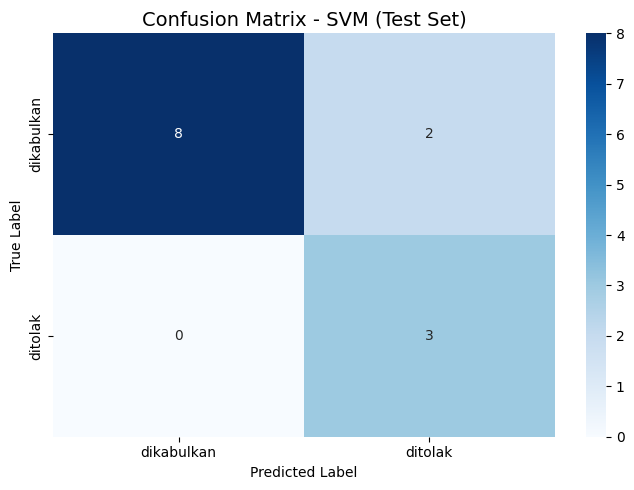

In [6]:
svm_model = LinearSVC(random_state=42, class_weight='balanced', max_iter=5000)
svm_model.fit(X_train_tfidf, y_train)

y_pred = svm_model.predict(X_test_tfidf)

# Evaluasi pada test set
acc = accuracy_score(y_test, y_pred)
print(f"=== EVALUASI MODEL SVM ===")
print(f"Accuracy Score (Test): {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Cross-Validation (jika cukup data)
print("\n=== CROSS-VALIDATION ===")
try:
    X_all_cv = tfidf_vectorizer.transform(df_cases['text_full'])
    y_all = df_cases['label']
    
    n_splits = min(5, len(df_cases['label'].value_counts().min()))  # Adaptif
    if n_splits >= 2:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = cross_val_score(LinearSVC(random_state=42, class_weight='balanced', max_iter=5000),
                                     X_all_cv, y_all, cv=cv, scoring='accuracy')
        print(f"CV Scores ({n_splits}-fold): {cv_scores}")
        print(f"CV Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        
        if cv_scores.mean() > 0.95 and acc == 1.0:
            print("\n[WARNING] Accuracy sangat tinggi — kemungkinan overfitting atau dataset terlalu homogen.")
    else:
        print("Dataset terlalu kecil untuk cross-validation stratified.")
except Exception as e:
    print(f"Cross-validation gagal: {e}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title("Confusion Matrix - SVM (Test Set)", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 7. Visualisasi Top TF-IDF Features

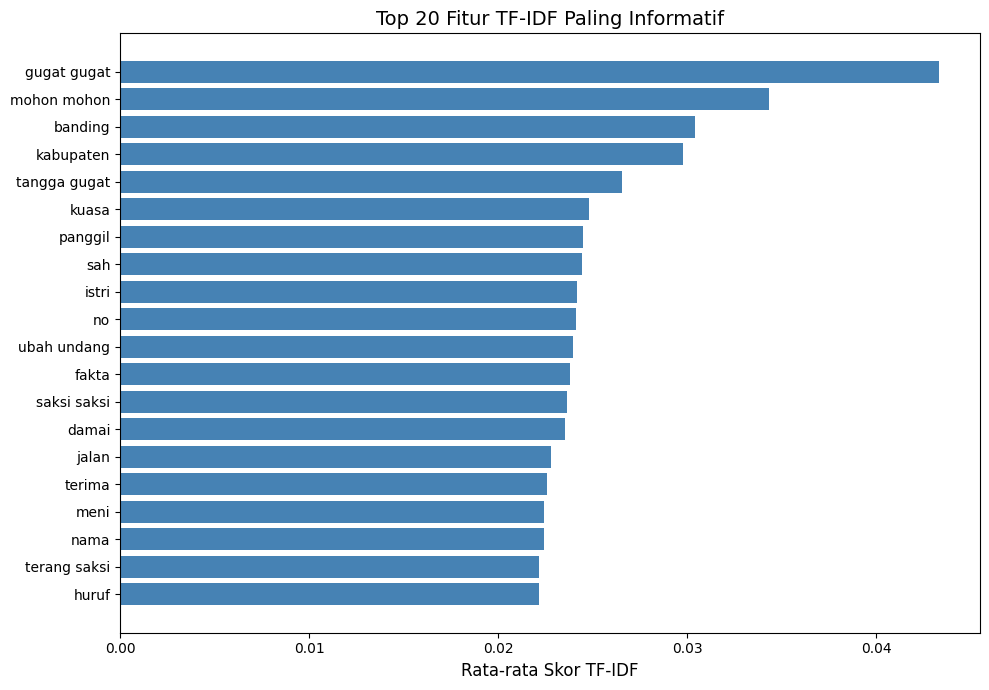

In [7]:
# Top 20 TF-IDF Features Bar Chart
top_20_names = [feature_names[i] for i in top_indices[:20]]
top_20_scores = [mean_tfidf[i] for i in top_indices[:20]]

plt.figure(figsize=(10, 7))
plt.barh(list(reversed(top_20_names)), list(reversed(top_20_scores)), color='steelblue')
plt.xlabel('Rata-rata Skor TF-IDF', fontsize=12)
plt.title('Top 20 Fitur TF-IDF Paling Informatif', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'data/eval/top_tfidf_features.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Fungsi Retrieval (IMPROVED)

Ditambahkan:
- **Similarity threshold** (filter skor < 0.01)
- **Retrieval explanation**

In [8]:
SIMILARITY_THRESHOLD = 0.01

def retrieve(query: str, k: int = 5, threshold: float = SIMILARITY_THRESHOLD):
    """
    Sistem Retrieval dengan Cosine Similarity + Threshold Filtering
    """
    query_clean = clean_query(query)
    query_vec = tfidf_vectorizer.transform([query_clean])
    similarity_scores = cosine_similarity(query_vec, X_all_tfidf).flatten()
    
    # Ranking
    top_k_indices = similarity_scores.argsort()[-k:][::-1]
    
    results = []
    for idx in top_k_indices:
        score = similarity_scores[idx]
        if score >= threshold:
            case = df_cases.iloc[idx]
            results.append({
                "case_id": case["case_id"],
                "similarity_score": round(float(score), 4),
                "label_solusi": case["label"],
                "no_perkara": case.get("no_perkara", "-"),
                "alasan": case.get("alasan_perceraian", "-")
            })
    
    return results

# Demo
print("=== DEMO RETRIEVAL ===\n")
demo_queries = [
    "suami tidak memberi nafkah dan sering bertengkar",
    "kekerasan dalam rumah tangga dipukul",
    "suami pergi meninggalkan rumah tanpa kabar"
]

for q in demo_queries:
    results = retrieve(q, k=3)
    print(f"Query: '{q}'")
    for r in results:
        print(f"  -> {r['case_id']} | Sim: {r['similarity_score']} | Label: {r['label_solusi']} | Alasan: {r['alasan']}")
    print()

=== DEMO RETRIEVAL ===

Query: 'suami tidak memberi nafkah dan sering bertengkar'
  -> case_059 | Sim: 0.0571 | Label: ditolak | Alasan: pertengkaran, ekonomi, meninggalkan, kekerasan, selingkuh
  -> case_010 | Sim: 0.0561 | Label: dikabulkan | Alasan: pertengkaran, ekonomi, meninggalkan, selingkuh
  -> case_024 | Sim: 0.0545 | Label: dikabulkan | Alasan: pertengkaran, ekonomi, meninggalkan, kekerasan, judi

Query: 'kekerasan dalam rumah tangga dipukul'
  -> case_002 | Sim: 0.077 | Label: ditolak | Alasan: pertengkaran, ekonomi, kekerasan, selingkuh
  -> case_012 | Sim: 0.0712 | Label: dikabulkan | Alasan: pertengkaran, ekonomi, meninggalkan, kekerasan, mabuk
  -> case_007 | Sim: 0.065 | Label: dikabulkan | Alasan: pertengkaran, ekonomi, meninggalkan, kekerasan, judi

Query: 'suami pergi meninggalkan rumah tanpa kabar'
  -> case_046 | Sim: 0.0767 | Label: dikabulkan | Alasan: pertengkaran, meninggalkan
  -> case_016 | Sim: 0.0647 | Label: dikabulkan | Alasan: pertengkaran, ekonomi, men

## 9. Similarity Distribution Visualization

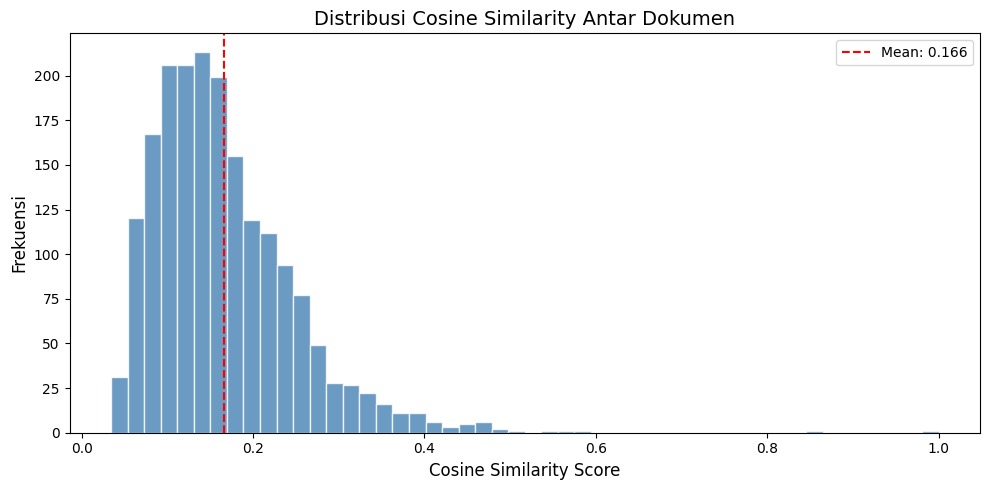

Statistik Similarity Antar-Dokumen:
  Min: 0.0342
  Max: 1.0000
  Mean: 0.1657
  Std: 0.0832


In [9]:
# Hitung similarity antar semua pasangan dokumen
all_sim = cosine_similarity(X_all_tfidf)

# Ambil nilai segitiga atas (tanpa diagonal)
upper_triangle = all_sim[np.triu_indices_from(all_sim, k=1)]

plt.figure(figsize=(10, 5))
plt.hist(upper_triangle, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(x=np.mean(upper_triangle), color='red', linestyle='--', label=f'Mean: {np.mean(upper_triangle):.3f}')
plt.xlabel('Cosine Similarity Score', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.title('Distribusi Cosine Similarity Antar Dokumen', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'data/eval/similarity_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Statistik Similarity Antar-Dokumen:")
print(f"  Min: {upper_triangle.min():.4f}")
print(f"  Max: {upper_triangle.max():.4f}")
print(f"  Mean: {upper_triangle.mean():.4f}")
print(f"  Std: {upper_triangle.std():.4f}")

## 10. Export Model & Queries Evaluasi

In [10]:
models_dir = os.path.join(base_path, "models")
eval_dir = os.path.join(base_path, "data/eval")
os.makedirs(models_dir, exist_ok=True)
os.makedirs(eval_dir, exist_ok=True)

# Simpan Model
joblib.dump(tfidf_vectorizer, os.path.join(models_dir, "tfidf_vectorizer.pkl"))
joblib.dump(svm_model, os.path.join(models_dir, "svm_classifier.pkl"))
print("Model TF-IDF dan SVM berhasil diekspor!")

# Buat queries evaluasi
queries_eval = [
    {"query": "suami tidak memberi nafkah", "ground_truth_case_id": df_cases.iloc[0]['case_id']},
    {"query": "terjadi perselisihan dan pertengkaran terus menerus", "ground_truth_case_id": df_cases.iloc[1]['case_id']},
    {"query": "suami pergi meninggalkan rumah tangga", "ground_truth_case_id": df_cases.iloc[2]['case_id']},
    {"query": "kekerasan dalam rumah tangga", "ground_truth_case_id": df_cases.iloc[3 % len(df_cases)]['case_id']},
    {"query": "suami selingkuh dengan wanita lain", "ground_truth_case_id": df_cases.iloc[4 % len(df_cases)]['case_id']}
]

with open(os.path.join(eval_dir, "queries.json"), "w", encoding="utf-8") as f:
    json.dump(queries_eval, f, indent=4, ensure_ascii=False)

print("Queries evaluasi berhasil diekspor!")
print("\nTahap 3 (Case Retrieval) — SELESAI!")

Model TF-IDF dan SVM berhasil diekspor!
Queries evaluasi berhasil diekspor!

Tahap 3 (Case Retrieval) — SELESAI!
